# Mapping the Sacred Sites: A LISA-Based Investigation of Shakti Pithas

This project is a demonstration of how spatial statistics can be applied to non-traditional datasets, blending qualitative cultural narratives with quantitative spatial analysis. It highlights the role of critical judgment at every stage starting from data construction and geocoding to statistical interpretation, underscoring that spatial analysis is as much about reasoning as it is about computation.

The project began with the compilation of Shakti Pitha locations from multiple publicly available textual and semi-structured sources, including online encyclopedic references. Since no authoritative spatial dataset exists for these sites, locations were initially collected as place names and descriptive location references rather than coordinates.

### Chapter 1 Raw Data Collection and Web Scraping

In [ ]:
import pandas as pd
import ssl
ssl._create_default_https_context = ssl._create_unverified_context
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
import time
import re

In [2]:
# Step 1: Read tables from Wikipedia
table = pd.read_html('https://en.wikipedia.org/wiki/Shakta_pithas')
print(len(table))

21


In [3]:
# Step 2: Extract main place/temple name
def split_locations(place):
    if pd.isna(place):
        return []
    # Split on 'A.' 'B.' 'C.' etc., but keep the letter for clarity
    parts = re.split(r'(?<!^)(?=\b[A-Z]\. )', place)
    return [p.strip(',; ') for p in parts if p.strip()]

expanded_rows = []
for idx, row in shakta_pithas_table.iterrows():
    locations = split_locations(row['Place'])
    if not locations:
        locations = [row['Place']]
    for loc in locations:
        expanded_rows.append({
            **row,
            'place_extracted': loc
        })

expanded_df = pd.DataFrame(expanded_rows)

In [16]:
expanded_df.to_csv('shakta_pithas.csv', index=False)

### Chapter 2 Geocoding and Spatial Validation

Cleaned place names were geocoded using open geocoding services and cross-validated against known regional boundaries. Because many sites are located in rural or historically defined areas, geocoding was treated as an iterative and interpretive process, ofte requiring manual corrections. The final output was a point-based spatial dataset suitable for statistical analysis.

In [23]:
# Step 3: Initialize geocoder
geolocator = Nominatim(user_agent="shakta_pithas_geocoder", timeout=10)
geocode = RateLimiter(geolocator.geocode, min_delay_seconds=2)

In [24]:
# Step 4: Define a function to geocode each location
def get_lat_lon(location):
    try:
        # Clean up location string if needed here
        loc = geocode(location)
        if loc:
            return pd.Series([loc.latitude, loc.longitude])
        else:
            return pd.Series([None, None])
    except Exception as e:
        print(f"Error geocoding '{location}': {e}")
        return pd.Series([None, None])

# Step 4: Apply geocoding to the relevant location column
shaktipitha[['Latitude', 'Longitude']] = shaktipitha['Location'].apply(get_lat_lon)

In [25]:
shaktipitha

,Sr. No.,Place,State in India/Country,Body part or ornament,Shakti,Bhairava,place_extracted,Location,Latitude,Longitude
0,1,"A. Amarnath Temple, from Srinagar through Paha...",Jammu and Kashmir,A. Throat B. Anklet,Mahamaya Devi,Trisandhyeshwar (Amarnath),"A. Amarnath Temple, from Srinagar through Paha...","Pahalgam, Jammu and Kashmir, India",34.014486,75.328516
1,1,"A. Amarnath Temple, from Srinagar through Paha...",Jammu and Kashmir,A. Throat B. Anklet,Mahamaya Devi,Trisandhyeshwar (Amarnath),B. Shri Parvat in Ladakh,"Ladakh, Jammu and Kashmir, India",NaN,NaN
2,2,Attahas Temple – At a village also named as At...,West Bengal,Lips,Phullara Devi,Vishveshwar,Attahas Temple – At a village also named as At...,"Labhpur, Birbhum, West Bengal, India",23.815299,87.800083
3,3,"Bahula Temple at Ketugram, 8 km from Katwa, Pu...",West Bengal,Left arm,Goddess Bahuladevi,Bhirukeshwar[27],"Bahula Temple at Ketugram, 8 km from Katwa, Pu...","Ketugram, Purba Bardhaman district, West Benga...",23.700870,88.047310
4,4,"Bakreshwar, on the banks of Paaphara river, 24...",West Bengal,Portion between the eyebrows,Mahishamardini devi,Vakranatheshwar,"Bakreshwar, on the banks of Paaphara river, 24...","Siuri, Birbhum, West Bengal, India",23.908054,87.527726
...,...,...,...,...,...,...,...,...,...,...
62,62,Aranya Devi Mandir at Badi Devisthan Shish Mah...,Bihar,Right thigh[31],Aranyani,Bhuma Bhairava,Aranya Devi Mandir at Badi Devisthan Shish Mah...,"Arrah, \tBhojpur District, Bihar, India",25.560317,84.663214
63,63,"Tuljabhavani Temple at Tuljapur, Dharashiv dis...",Maharashtra,NaN,Tuljabhavani Devi,Bhairava,"Tuljabhavani Temple at Tuljapur, Dharashiv dis...","Tuljapur, Dharashiv District, Maharashtra, India",18.008662,76.070792
64,64,"Mata Vaishno Devi Temple in Katra, Jammu",Jammu and Kashmir,Skull/Right arm[32],Vaishno Devi,Bhairava Baba,"Mata Vaishno Devi Temple in Katra, Jammu","Katra, Reasi District, Jammu and Kashmir, India",32.992486,74.931813
65,65,"त्रिपुर सुंदरी मंदिर, बांसवाड़ा Maa Tripura Su...",Rajasthan,NaN,Goddess Tripura Sundari as Rajarajeshwari तरता...,Aanand Bhairava,"त्रिपुर सुंदरी मंदिर, बांसवाड़ा Maa Tripura Su...","Udaipur, Gomati District, Tripura, India",23.541616,91.491759


In [26]:
# Step 5: Save to CSV
shaktipitha.to_csv('shaktapithas_geos.csv', index=False)
print("File saved as 'shaktapithas_geos.csv'.")

File saved as 'shaktapithas_geos.csv'.


### Chapter 3 Exploratory Analysis and Mapping

Next, the dataset was explored visually and analytically to understand its spatial structure. Spatial weights matrices were constructed based on distance relationships to define neighborhood influence among sites. Local Indicators of Spatial Association (LISA) were applied to identify statistically significant clusters and spatial outliers among locations.

In [2]:
import pandas as pd
import geopandas as gpd
import folium
from shapely.geometry import Point
from geopy.distance import geodesic
import numpy as np
from folium.plugins import BeautifyIcon

In [3]:
sp = pd.read_csv('shaktapithas_geos.csv', encoding='ISO-8859-1') 

In [4]:
def to_float(x):
    try:
        return float(x)
    except:
        return None

sp['Latitude'] = sp['Latitude'].apply(to_float)
sp['Longitude'] = sp['Longitude'].apply(to_float)

In [5]:
# Step 6: Drop duplicates (to avoid identical entries like Amarnath)
sp_clean = sp.drop_duplicates(subset=["Place", "Latitude", "Longitude"]).reset_index(drop=True)

# Check number of unique entries
sp_clean.shape, sp_clean[['Place', 'Latitude', 'Longitude']].head()

((67, 9),
                                                Place   Latitude  Longitude
 0  A. Amarnath Temple, from Srinagar through Paha...  34.014486  75.328516
 1  A. Amarnath Temple, from Srinagar through Paha...  33.277839  75.341218
 2  Attahas Temple â At a village also named as ...  23.815299  87.800083
 3  Bahula Temple at Ketugram, 8Â km from Katwa, P...  23.700870  88.047310
 4  Bakreshwar, on the banks of Paaphara river, 24...  23.908054  87.527726)

In [6]:
# Step 7: Initial map
geometry = [Point(xy) for xy in zip(sp.Longitude, sp.Latitude)]
gdf = gpd.GeoDataFrame(sp, geometry=geometry, crs='EPSG:4326') 

In [7]:
m = folium.Map(location=[sp.Latitude.mean(), sp.Longitude.mean()], zoom_start=5)
for _, row in gdf.iterrows():
    folium.Marker(location=[row['Latitude'], row['Longitude']]).add_to(m)

m 

To explore the mythological journey of Shiva carrying Sati’s body, the spatial problem was framed using a Traveling Salesman–style approach. In simple terms, the Traveling Salesman Problem (TSP) asks a very practical question:
If someone must visit a set of locations once, what is the shortest possible route that connects them all?
For instace lets consider a delivery person who needs to stop at many cities and wants to minimize total travel distance. The challenge is not finding a route, but finding the most efficient one.

Although the journey of Shiva is mythological, it implicitly describes movement across space. By treating Shakti Pithas as fixed points on a map, the mythological narrative can be examined through a spatial lens. TSA framework provides a neutral spatial baseline against which the narrative can be interpreted.

### Chapter 4 Route Modeling and Spatial Interpretation

In [8]:
coords = list(zip(sp['Latitude'], sp['Longitude']))

# Step 8: TSP approach
def nearest_neighbor_tsp(coords):
    n = len(coords)
    visited = [False] * n
    path = [0]  # Start from first point
    visited[0] = True

    for _ in range(n - 1):
        last = path[-1]
        nearest = None
        min_dist = float('inf')
        for i in range(n):
            if not visited[i]:
                dist = geodesic(coords[last], coords[i]).km
                if dist < min_dist:
                    min_dist = dist
                    nearest = i
        path.append(nearest)
        visited[nearest] = True

    return path

path_order = nearest_neighbor_tsp(coords)
ordered_coords = [coords[i] for i in path_order]


In [9]:
route = folium.Map(location=[np.mean(sp.Latitude), np.mean(sp.Longitude)], zoom_start=5)
folium.PolyLine(locations=ordered_coords, color='blue', weight=3).add_to(route)
for i, (lat, lon) in enumerate(ordered_coords):
    folium.Marker([lat, lon], popup=f"Stop {i+1}").add_to(route)
route

Now, we turn abstract locations into an interpretable, story-driven map so that each sacred site clickable and informative. Here, the line represents a symbolic journey, not a literal travel route which visually reinforces the idea of movement across space.

In [10]:
# Step 9: Create a map centered over South Asia
m = folium.Map(location=[25, 85], zoom_start=5, tiles="CartoDB Positron")

In [12]:
# pop-ups and icons
for _, row in sp_clean.iterrows():
    popup_html = f"""
    <b>Shakti:</b> {row['Shakti']}<br>
    <b>Bhairava:</b> {row['Bhairava']}<br>
    <b>Body Part:</b> {row['Body part or ornament']}<br>
    <b>Region:</b> {row['State in India/Country']}
    """
    icon = BeautifyIcon(
        icon_shape="marker",
        number="🕉️",
        border_color="red",
        text_color="white",
        background_color="white"
    )
    folium.Marker(
        location=[row['Latitude'], row['Longitude']],
        popup=folium.Popup(popup_html, max_width=300),
        icon=icon
    ).add_to(m)

In [13]:
# Symbolic path: connect all points in sequence (optional: optimize this later)
path_coords = sp_clean[['Latitude', 'Longitude']].values.tolist()
folium.PolyLine(locations=path_coords, color='darkviolet', weight=3, tooltip="Path of Shiva").add_to(m)

m

After mapping the Shakti Pithas and visualizing their symbolic connections, the next question is analytical:
* Are these sacred sites randomly distributed, or do they form meaningful spatial clusters?
Human eyes are good at seeing patterns but they are bad at knowing whether those patterns are statistically real. As such, Moran’s I is used here to move from visual impression to formal spatial inference.
    
Moran’s I is a measure of spatial autocorrelation.
* Positive Moran’s I → similar values cluster together
* Negative Moran’s I → neighboring values are dissimilar
* Near zero → spatial randomness

Moran’s I was used to formally test whether Shakti Pithas exhibit statistically significant spatial clustering. Because point locations alone do not capture concentration, Kernel Density Estimation (KDE) was first applied to convert site locations into local density values. Global Moran’s I assessed whether dense and sparse areas are spatially correlated across the study region, while Local Moran’s I (LISA) identified specific clusters and spatial outliers. This approach moves the analysis beyond visual interpretation, providing quantitative evidence that sacred sites are regionally structured rather than randomly distributed.

In [21]:
import pandas as pd
import numpy as np
from esda.moran import Moran
from libpysal.weights import DistanceBand
from sklearn.neighbors import KernelDensity
from esda.moran import Moran
from libpysal.weights import DistanceBand
from esda.moran import Moran_Local
import matplotlib.pyplot as plt

In [22]:
# Step 10: Moran's I and KDE 
coords = sp_clean[['Latitude', 'Longitude']].values
kde = KernelDensity(kernel='gaussian', bandwidth=2).fit(coords)
density_scores = kde.score_samples(coords)  # Higher = denser
w = DistanceBand(coords, threshold=10, binary=True, silence_warnings=True)
moran = Moran(density_scores, w)

print("Moran's I:", moran.I)
print("p-value:", moran.p_sim)

Moran's I: 0.4262286935498064
p-value: 0.001


In [23]:
coords = sp_clean[['Latitude', 'Longitude']].values
kde = KernelDensity(kernel='gaussian', bandwidth=2).fit(coords)
density_scores = kde.score_samples(coords)  # Higher = denser

# Applyimg Local Moran's I (LISA) on density scores
w = DistanceBand(coords, threshold=10, binary=True, silence_warnings=True)
moran_local = Moran_Local(density_scores, w)

print("Local Moran's I values:", moran_local.Is[:10])  # Show first 10 values
print("Local p-values:", moran_local.p_sim[:10])      # Show first 10 p-values
print("Cluster types:", moran_local.q[:10])           # Show first 10 quadrant classifications

# Get significant clusters (p < 0.05)
significant_mask = moran_local.p_sim < 0.05
significant_locations = np.where(significant_mask)[0]

print(f"\nNumber of significant locations: {len(significant_locations)}")
print(f"Total locations analyzed: {len(density_scores)}")

# Interpret quadrant classifications
quadrant_labels = {0: 'Not significant', 1: 'HH (High-High)', 2: 'LH (Low-High)', 
                  3: 'LL (Low-Low)', 4: 'HL (High-Low)'}

for i in significant_locations[:5]:  # Show first 5 significant locations
    print(f"Location {i}: {quadrant_labels[moran_local.q[i]]}, "
          f"Local I = {moran_local.Is[i]:.4f}, p-value = {moran_local.p_sim[i]:.4f}")


Local Moran's I values: [ 0.04610956 -0.03261488  0.60253829  0.60857216  0.58949761  0.73082863
  0.66708549  0.16429297 -0.35081315  1.21099426]
Local p-values: [0.084 0.074 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001]
Cluster types: [3 4 1 1 1 3 1 1 2 3]

Number of significant locations: 63
Total locations analyzed: 67
Location 2: HH (High-High), Local I = 0.6025, p-value = 0.0010
Location 3: HH (High-High), Local I = 0.6086, p-value = 0.0010
Location 4: HH (High-High), Local I = 0.5895, p-value = 0.0010
Location 5: LL (Low-Low), Local I = 0.7308, p-value = 0.0010
Location 6: HH (High-High), Local I = 0.6671, p-value = 0.0010


Unlike the symbolic path used for initial visualization, the followig step implements a formal Traveling Salesman Problem (TSP) optimization. Pairwise geodesic distances between all Shakti Pithas were computed and used to derive an approximate shortest route connecting all sites. This optimized path serves as a spatial baseline, allowing comparison between distance-efficient connectivity and the statistically detected clustering patterns identified through Moran’s I and LISA. The contrast highlights that sacred site distribution reflects regional and cultural structuring rather than purely spatial efficiency.

In [27]:
import folium
import numpy as np
import pandas as pd
from python_tsp.heuristics import solve_tsp_simulated_annealing
from geopy.distance import geodesic
from folium.plugins import BeautifyIcon
from folium.plugins import PolyLineTextPath
from folium import Element
from folium.plugins import AntPath
import base64
from folium.plugins import FloatImage

In [28]:
# Step 12: Construct optimal route order
def calculate_distance_matrix(coords):
    """Calculate distance matrix between all points using geodesic distance"""
    n = len(coords)
    distance_matrix = np.zeros((n, n))
    
    for i in range(n):
        for j in range(n):
            if i != j:
                distance_matrix[i][j] = geodesic(coords[i], coords[j]).kilometers
            else:
                distance_matrix[i][j] = 0
    
    return distance_matrix

coords = [(row['Latitude'], row['Longitude']) for _, row in sp_clean.iterrows()]
distance_matrix = calculate_distance_matrix(coords)


In [29]:
distance_matrix[:, 0] = 0
permutation, total_distance = solve_tsp_simulated_annealing(distance_matrix)

# Create ordered coordinates
ordered_coords = [coords[i] for i in permutation]
ordered_data = sp_clean.iloc[permutation].reset_index(drop=True)

print(f"Total route distance: {total_distance:.2f} km")
print(f"Route order: {permutation}")

Total route distance: 13210.45 km
Route order: [0, 1, 64, 46, 60, 13, 18, 35, 31, 10, 29, 9, 5, 61, 51, 23, 45, 44, 28, 22, 8, 26, 24, 62, 42, 30, 32, 36, 52, 63, 66, 38, 17, 56, 25, 48, 37, 34, 50, 53, 55, 7, 43, 20, 58, 14, 12, 39, 27, 40, 65, 11, 15, 21, 57, 6, 19, 54, 59, 33, 2, 3, 49, 41, 16, 4, 47]


In [30]:
m = folium.Map(location=[25, 85], zoom_start=5, tiles="CartoDB Positron")

# Develop smooth path connecting all points
folium.PolyLine(
    locations=ordered_coords,
    color='#2E86AB',  
    weight=2.0,
    opacity=0.8,
    dash_array="5, 10",
    smooth_factor=25.0,  
    tooltip=f"Approx Route - Total Distance: {total_distance:.1f} km"
).add_to(m)

# Add popups
for idx, (_, row) in enumerate(ordered_data.iterrows()):
    popup_html = f"""
    <b>Shakti:</b> {row['Shakti']}<br>
    <b>Bhairava:</b> {row['Bhairava']}<br>
    <b>Body Part:</b> {row['Body part or ornament']}<br>
    <b>Location:</b> {row['Location']}
    """
    
    icon = BeautifyIcon(
        icon_shape="marker",
        number=str(idx + 1),  # Show route order
        border_color="",
        text_color="white",
        background_color="darkred"
    )
    
    folium.Marker(
        location=[row['Latitude'], row['Longitude']],
        popup=folium.Popup(popup_html, max_width=300),
        icon=icon
    ).add_to(m)

# Add title and summary information at the top
combined_html = '''
<link href="https://fonts.googleapis.com/css2?family=Noto+Serif&display=swap" rel="stylesheet">
<!-- Title at the top center -->
<div style="position: fixed; top: 10px; left: 75%; transform: translateX(-50%);
     z-index: 9999; font-size: 20px; font-weight: bold; background-color: white;
     padding: 5px; opacity: 0.9; font-family: 'Noto Serif', serif;">
     The Sacred Journey   <br>
     <span style="font-size: 12px; font-weight: normal;">
         Approximate mythological route of Shiva's journey derived using a Traveling Salesman Problem (TSP) algorithm. This sequence connects Shakti Pithas based on minimized geodesic distance, reflecting a spatial interpretation of the sacred narrative.
     </span>
</div>

<!-- Disclaimer at the bottom left -->
<div style="position: fixed; bottom: 5px; left: 5px; 
     z-index: 9999; font-size: 10px; background-color: white; padding: 5px; border: 1px solid grey; opacity: 0.85;">
     <b>Disclaimer:</b> This map is for informational and cultural purposes only. <br>
     The locations and details of Shakti Pithas are based on publicly available sources and may not be definitive.<br>
     <b>Data:</b> <a href="https://en.wikipedia.org/wiki/Shakta_pithas" target="_blank">Wikipedia: Shakta pithas</a> (accessed June 2025).
</div>
'''

m.get_root().html.add_child(Element(combined_html))
m.save('sacred_journey.html')
m

Finally, we converts statistically significant LISA results into an interactive map, highlighting spatial clusters and outliers of Shakti Pithas with clear visual cues and explanatory legends.

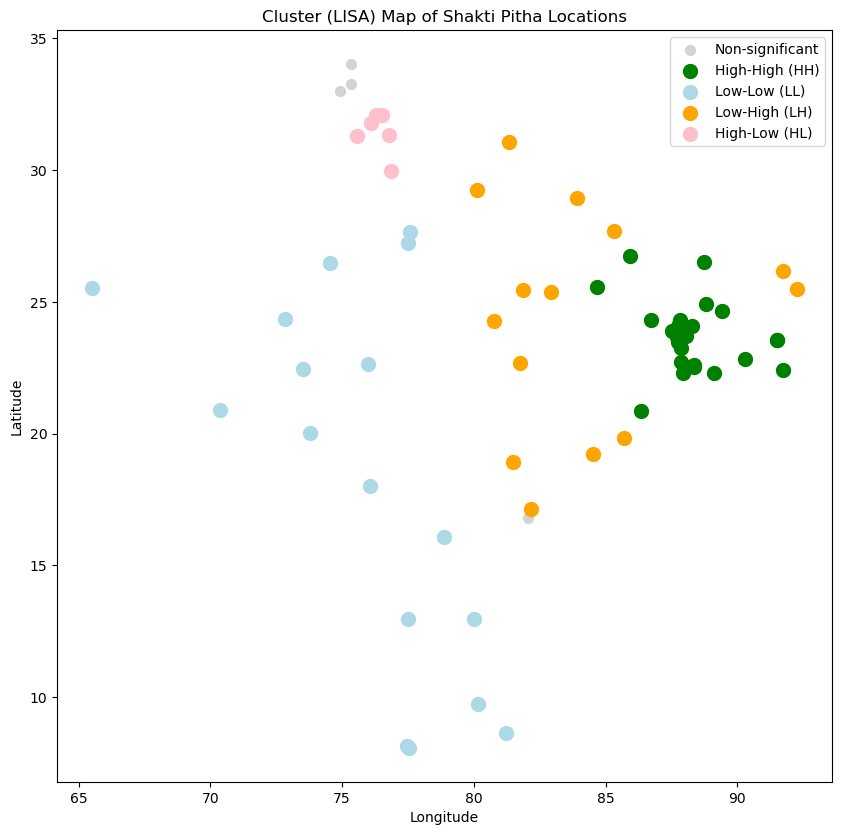

In [27]:
# Step 13: Construct optimal route order
coords = sp_clean[['Latitude', 'Longitude']].values
kde = KernelDensity(kernel='gaussian', bandwidth=2).fit(coords)
density_scores = kde.score_samples(coords)

w = DistanceBand(coords, threshold=10, binary=True, silence_warnings=True)
moran_local = Moran_Local(density_scores, w)

geometry = [Point(xy) for xy in zip(sp_clean['Longitude'], sp_clean['Latitude'])]
gdf = gpd.GeoDataFrame(sp_clean, geometry=geometry)

gdf['Local_I'] = moran_local.Is
gdf['p_value'] = moran_local.p_sim
gdf['cluster_type'] = moran_local.q

cluster_colors = {
    1: 'green',        # High-High (HH)
    3: 'lightblue',       # Low-Low (LL)
    2: 'orange',  # Low-High (LH)
    4: 'pink'        # High-Low (HL)
}

# When filtering, use .copy()
significant_gdf = gdf[gdf['p_value'] < 0.05].copy()
significant_gdf.loc[:, 'color'] = significant_gdf['cluster_type'].map(cluster_colors)
significant_gdf['color'] = significant_gdf['cluster_type'].map(cluster_colors)

fig, ax = plt.subplots(figsize=(10, 10))
gdf.plot(ax=ax, color='lightgray', markersize=50, label='Non-significant')

# Plot each significant cluster type
for cluster_type, color in cluster_colors.items():
    subset = significant_gdf[significant_gdf['cluster_type'] == cluster_type]
    subset.plot(ax=ax, color=color, markersize=100, label=f'{color} Cluster')
plt.legend(['Non-significant', 'High-High (HH)', 'Low-Low (LL)', 'Low-High (LH)', 'High-Low (HL)'])
plt.title('Cluster (LISA) Map of Shakti Pitha Locations')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(False)
plt.show()


Here, each significant location is shown as a colored circular marker, where the color represents its LISA cluster type (High–High, Low–Low, Low–High, or High–Low). Clicking on a marker reveals a pop-up with the cluster classification, local Moran’s I value, and site information, allowing users to explore spatial patterns interactively. Additionally, a custom title and legend are added directly to the map using HTML, explaining the meaning of each cluster type and ensuring the map is self-explanatory without requiring prior knowledge of spatial statistics. The final output is saved as an HTML file, producing a shareable, browser-based visualization that links statistical spatial analysis with intuitive geographic exploration.

In [99]:
m_LISA = folium.Map(location=[25, 85], zoom_start=5, tiles="CartoDB Positron")
for _, row in significant_gdf.iterrows():
    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=7,
        color=row['color'],
        fill=True,
        fill_color=row['color'],
        fill_opacity=0.6,
        popup=f"Cluster: {row['cluster_type']}<br>"
        f"Moran's I: {row['Local_I']:.2f}<br>"
        f"Location: {row['Location']}<br>"
    ).add_to(m_LISA)

# Add a legend for cluster types and colors
legend_html = '''


<div style="position: fixed; top: 10px; left: 50%; transform: translateX(-50%); 
     z-index: 9999; font-family: 'Noto Serif', serif; font-size: 20px; font-weight: bold; background-color: white; padding: 10px; opacity: 0.9;">
     Mapping the Sacred: LISA Cluster Map of Shakti Pithas <br>
</div>

<div style="position: fixed; bottom: 30px; left: 75%; transform: translateX(-50%); 
     z-index: 9999; font-size: 12px; background-color: white; padding: 10px; opacity: 0.9; width: 300px;">
     <b>What This Map Shows</b><br>
     <span style="color:green;">Green (HH)</span>: Locations where high-density points cluster together.<br>
     <span style="color:lightblue;">LightBlue (LL)</span>: Locations where low-density points cluster together.<br>
     <span style="color:orange;">Orange (LH)</span>: Outliers where low values are surrounded by high values.<br>
     <span style="color:pink;">Pink (HL)</span>: Outliers where high values are surrounded by low values.<br>
</div>
'''
title = Element(legend_html)
m_LISA.get_root().html.add_child(title)

m_LISA.save('lisa_clusters.html')
m_LISA

This project demonstrates how point-based geospatial data—when paired with spatial statistics and optimization techniques—can be transformed into meaningful analytical insights. By combining density estimation, Local Moran’s I (LISA), and route optimization, the analysis reveals both regional clustering and symbolic connectivity embedded within sacred geographies.

Several advanced spatial analyses could further extend this work:

* Multi-scale spatial autocorrelation: Repeating LISA and Moran’s I across varying distance thresholds or adaptive kernels to test how clustering patterns change with spatial scale and to identify core versus peripheral sacred regions.
* Network-constrained analysis: Modeling connectivity using historical trade routes, pilgrimage paths, or terrain-aware cost surfaces instead of straight-line distances, allowing mythological movement to be examined under realistic geographic constraints.
* Probabilistic and uncertainty-aware mapping: Explicitly modeling locational uncertainty for mythologically ambiguous sites using spatial buffers or Bayesian approaches, improving interpretive transparency.

Together, these extensions highlight how even simple point datasets can support sophisticated spatial reasoning when treated as analytical objects rather than cartographic endpoints. OM !!!